# GDGoC ML Study Jam - Chapter 1 Challenge
by Nadhif Rif'at Rasendriya

## **Topic: The Smartphone Analyst**

Selamat datang, Data Detective! 🕵️‍♂️

Hari ini, kita tidak hanya belajar koding, tapi belajar **memecahkan masalah menggunakan data**.

**Skenario:**
Kamu adalah Lead Data Analyst di sebuah toko gadget besar. Bosmu memberikan dataset spesifikasi smartphone dan memintamu menjawab **10 Pertanyaan Bisnis** untuk strategi penjualan bulan depan.

**Aturan Main:**
1.  **Bebas Berkreasi:** Gunakan metode apapun (Filtering, Sorting, Grouping, atau Visualisasi Grafik).
2.  **Wajib Ada Insight:** Setelah kode dijalankan, tulis kesimpulanmu di cell Teks di bawahnya.
3.  **Have Fun!**

In [4]:
# ⚠️ JALANKAN CELL INI TERLEBIH DAHULU!
# Script ini akan membuat dataset dummy untuk latihan kita hari ini.

import pandas as pd
import numpy as np
import random

np.random.seed(42)

# Data Dummy
n_data = 150
brands = ['Samsung', 'Apple', 'Xiaomi', 'Oppo', 'Vivo', 'Realme', 'Infinix', 'Asus', 'Google']
rams = [4, 6, 8, 12, 16, 24] # Ada RAM 24GB buat gaming
storages = [64, 128, 256, 512, 1024]

data = {
    'Brand': [random.choice(brands) for _ in range(n_data)],
    'Model': [f"Phone {i}" for i in range(n_data)],
    'RAM_GB': [random.choice(rams) for _ in range(n_data)],
    'Storage_GB': [random.choice(storages) for _ in range(n_data)],
    'Rating': [round(random.uniform(3.0, 5.0), 1) for _ in range(n_data)]
}

df = pd.DataFrame(data)

# Bikin harga agak logis -> (RAM gede + Storage gede = Mahal) + sedikit random noise
df['Price_Juta'] = (df['RAM_GB'] * 0.5) + (df['Storage_GB'] * 0.015) + np.random.randint(1, 4, n_data)
df['Price_Juta'] = df['Price_Juta'].round(1)

# Tambahin Data -> "Aneh" (Anomaly)
df.loc[148] = ['Nokia', 'Nokia 3310 Reborn', 2, 16, 50.0, 5.0] # HP kentang harga sultan
df.loc[149] = ['Unknown', 'Prototype X', 128, 2048, 0.5, 1.0] # Spek dewa harga permen

print("Dataset 'smartphones' berhasil dibuat!")
print(f"Total Data: {len(df)} baris.")
df.head(10)

Dataset 'smartphones' berhasil dibuat!
Total Data: 150 baris.


,Brand,Model,RAM_GB,Storage_GB,Rating,Price_Juta
0,Apple,Phone 0,6,64,3.4,7.0
1,Samsung,Phone 1,16,128,3.1,10.9
2,Asus,Phone 2,12,512,3.1,16.7
3,Apple,Phone 3,24,256,5.0,18.8
4,Apple,Phone 4,12,64,4.2,8.0
5,Google,Phone 5,24,512,3.8,20.7
6,Google,Phone 6,6,512,3.1,13.7
7,Google,Phone 7,12,1024,3.4,23.4
8,Asus,Phone 8,8,1024,4.4,22.4
9,Asus,Phone 9,6,1024,3.2,21.4


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

---
### **Quest 1: Cek Ombak (Overview)**
Sebelum masuk ke analisis dalam, coba cek dulu isi gudang kita.
1. Ada berapa baris dan kolom di data ini?
2. Apa saja nama kolomnya?
3. Tampilkan statistik dasarnya (Rata-rata, Max, Min).

*Hint: Gunakan `.shape`, `.columns`, dan `.describe()`.*

In [6]:
print("Jumlah Baris & Kolom:", df.shape)
print("\nNama Kolom:")
print(df.columns.tolist())

print("\nStatistik Dasar:")
df.describe()

Jumlah Baris & Kolom: (150, 6)

Nama Kolom:
['Brand', 'Model', 'RAM_GB', 'Storage_GB', 'Rating', 'Price_Juta']

Statistik Dasar:


,RAM_GB,Storage_GB,Rating,Price_Juta
count,150.000000,150.000000,150.000000,150.00000
mean,12.360000,443.413333,4.359333,14.27600
std,11.849322,377.020858,3.811711,6.77286
min,2.000000,16.000000,0.500000,1.00000
25%,6.000000,128.000000,3.600000,8.80000
50%,8.000000,256.000000,4.100000,12.80000
75%,16.000000,512.000000,4.600000,18.77500
max,128.000000,2048.000000,50.000000,30.40000


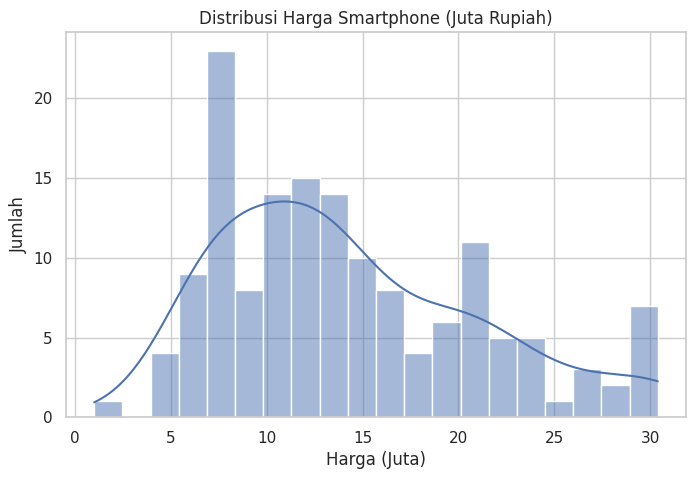

In [7]:
sns.histplot(df['Price_Juta'], bins=20, kde=True)
plt.title("Distribusi Harga Smartphone (Juta Rupiah)")
plt.xlabel("Harga (Juta)")
plt.ylabel("Jumlah")
plt.show()

#### 1. Dataset terdiri dari 150 baris dan 6 kolom, yang merepresentasikan 150 model smartphone dengan spesifikasi inti dan harga.

#### 2. Struktur kolom ideal untuk analisis karena mencakup brand, model, performa (RAM & Storage), persepsi pengguna (Rating), dan harga/price (juta).

#### 3. Statistik dasar menunjukkan adanya rentang harga dan spesifikasi yang cukup lebar, menandakan pasar yang beragam dari entry-level hingga ekstrem.

---
### **Quest 2: Raja Pasar**
Brand apa yang paling banyak memiliki model HP dalam daftar ini?

*Hint: Gunakan `.value_counts()`.*

In [8]:
brand_counts = df['Brand'].value_counts()
brand_counts

,count
Brand,
Google,21
Realme,19
Asus,18
Infinix,16
Apple,16
Oppo,16
Samsung,15
Xiaomi,14
Vivo,13


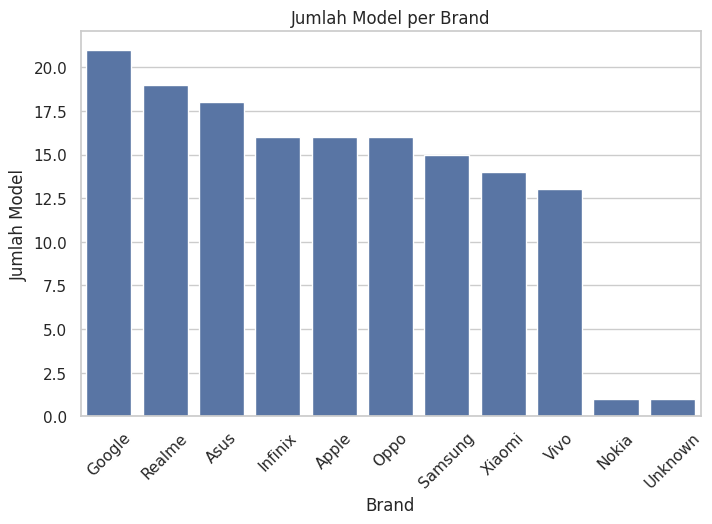

In [9]:
sns.barplot(x=brand_counts.index, y=brand_counts.values)
plt.title("Jumlah Model per Brand")
plt.xlabel("Brand")
plt.ylabel("Jumlah Model")
plt.xticks(rotation=45)
plt.show()

Brand dengan jumlah model terbanyak yang menunjukkan dominasi stok dan variasi produk di gudang yaitu **GOOGLE** dengan **21 model hp**.

Brand ini berpotensi menjadi core utama penjualan volume, cocok buat promo massal, bundling, atau penempatan utama di katalog.

---
### **Quest 3: Storage Wars**
Zaman sekarang aplikasi makin besar.
Coba cari HP yang punya **Storage paling besar** (Max Storage). Ada berapa HP yang punya storage segitu?

*Hint: Cari nilai max dulu, lalu filter datanya.*

In [10]:
max_storage = df['Storage_GB'].max()
hp_max_storage = df[df['Storage_GB'] == max_storage]

max_storage, len(hp_max_storage)

(2048, 1)

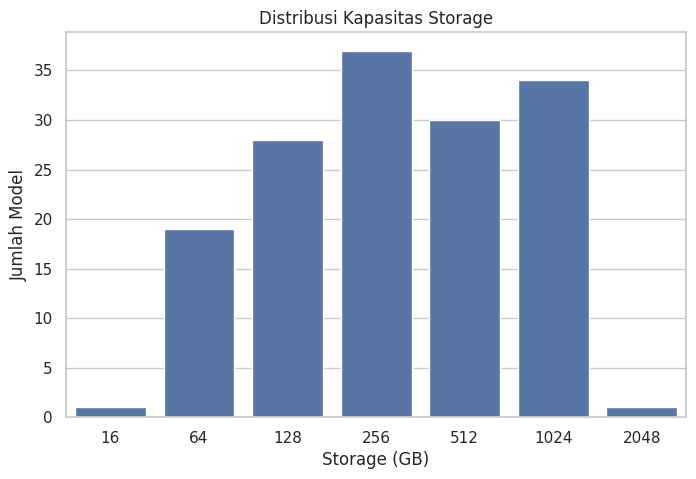

In [11]:
sns.countplot(x='Storage_GB', data=df, order=sorted(df['Storage_GB'].unique()))
plt.title("Distribusi Kapasitas Storage")
plt.xlabel("Storage (GB)")
plt.ylabel("Jumlah Model")
plt.show()

- Storage maksimum: **2048 GB** (2 TB)
- Jumlah HP dengan storage tersebut: **1 unit**

Di tengah kebutuhan storage yang terus naik, hanya satu HP yang benar-benar ‘menang perang’ di level 2 TB. So, ini membuktikan bahwa ini bukan soal kebutuhan massal, tapi soal dominasi teknologi.

---
### **Quest 4: Budget vs Premium**
Bos ingin tahu rentang harga pasar.
1. Berapa harga HP **termurah**?
2. Berapa harga HP **termahal**?

*Hint: Gunakan `.min()` dan `.max()` pada kolom harga.*

In [12]:
df['Price_Juta'].min(), df['Price_Juta'].max()

(1.0, 30.4)

In [18]:
harga_termurah = df['Price_Juta'].min()
harga_termahal = df['Price_Juta'].max()

print("Harga termurah:", harga_termurah, "juta")
print("Harga termahal:", harga_termahal, "juta")

Harga termurah: 1.0 juta
Harga termahal: 30.4 juta


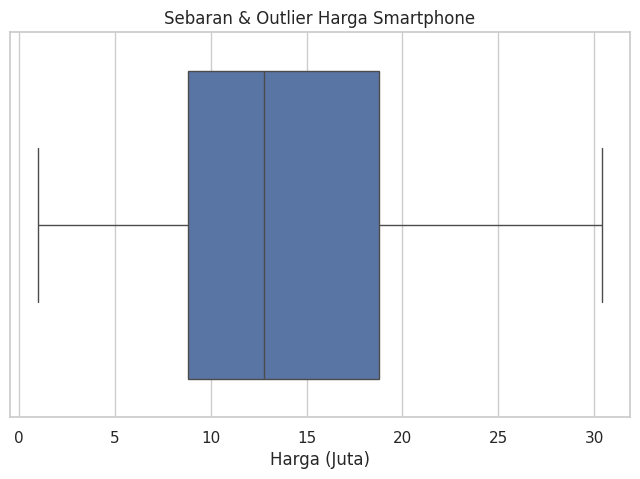

In [13]:
sns.boxplot(x=df['Price_Juta'])
plt.title("Sebaran & Outlier Harga Smartphone")
plt.xlabel("Harga (Juta)")
plt.show()

#### 1. Harga HP termurah: Rp 1 juta
#### 2. Harga HP termahal: Rp 30,4 juta

Rentang pasar sangat lebar (1 - 30,4 juta)
Ini menandakan pasar HP sangat terfragmentasi:
- Di satu sisi: entry-level / feature phone / secondary device
- Di sisi lain: flagship premium / luxury smartphone

---
### **Quest 5: The Gaming Beast**
Seorang Gamer datang mencari HP. Syaratnya mutlak:
1. **RAM wajib di atas 12 GB.**
2. **Storage minimal 512 GB.**

Tampilkan daftar HP yang memenuhi syarat tersebut!

*Hint: Gunakan Filtering dengan logika AND (`&`).*

In [19]:
gaming_hp = df[(df['RAM_GB'] > 12) & (df['Storage_GB'] >= 512)]
gaming_hp

,Brand,Model,RAM_GB,Storage_GB,Rating,Price_Juta
5,Google,Phone 5,24,512,3.8,20.7
10,Vivo,Phone 10,16,1024,3.0,26.4
15,Realme,Phone 15,24,1024,3.6,28.4
16,Realme,Phone 16,24,1024,3.1,29.4
31,Google,Phone 31,16,1024,3.0,26.4
45,Realme,Phone 45,24,1024,4.9,30.4
54,Apple,Phone 54,24,512,4.6,21.7
55,Realme,Phone 55,16,512,4.6,18.7
60,Samsung,Phone 60,16,1024,5.0,25.4
69,Realme,Phone 69,16,1024,3.6,24.4


In [22]:
gaming_hp = df[
    (df['RAM_GB'] > 12) &
    (df['Storage_GB'] >= 512)
    ]
gaming_hp

,Brand,Model,RAM_GB,Storage_GB,Rating,Price_Juta
5,Google,Phone 5,24,512,3.8,20.7
10,Vivo,Phone 10,16,1024,3.0,26.4
15,Realme,Phone 15,24,1024,3.6,28.4
16,Realme,Phone 16,24,1024,3.1,29.4
31,Google,Phone 31,16,1024,3.0,26.4
45,Realme,Phone 45,24,1024,4.9,30.4
54,Apple,Phone 54,24,512,4.6,21.7
55,Realme,Phone 55,16,512,4.6,18.7
60,Samsung,Phone 60,16,1024,5.0,25.4
69,Realme,Phone 69,16,1024,3.6,24.4


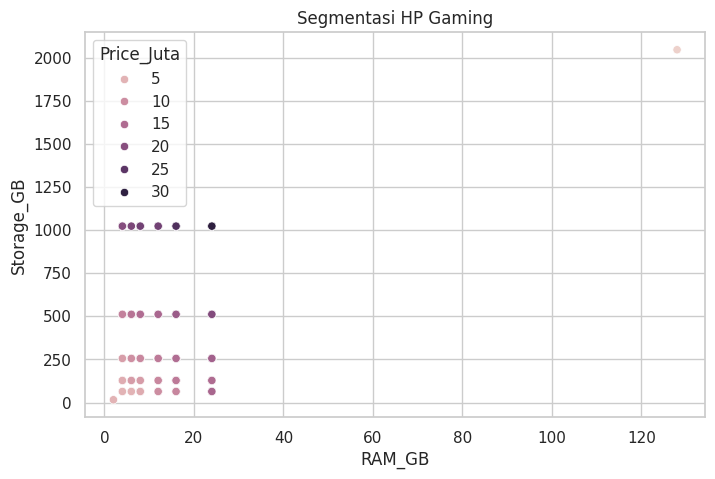

In [20]:
sns.scatterplot(data=df, x='RAM_GB', y='Storage_GB', hue='Price_Juta')
plt.title("Segmentasi HP Gaming")
plt.show()

Daftar hp yang memenuhi syarat:
- Realme (paling dominan)
- Vivo
- Google
- Samsung
- Oppo
- Xiaomi
- Apple
- Asus
- Infinix

- 1 Prototype X (anomali data) -> harusnya ditandai dulu

---
### **Quest 6: Sobat Mahasiswa**
Mahasiswa biasanya cari HP yang "Worth it".
Cari HP yang harganya **di bawah 7 Juta**, TAPI **Rating-nya di atas 4.5**.

Ada nggak barangnya?

In [23]:
student_hp = df[(df['Price_Juta'] < 7) & (df['Rating'] > 4.5)]
student_hp

,Brand,Model,RAM_GB,Storage_GB,Rating,Price_Juta
50,Oppo,Phone 50,6,128,4.6,6.9
85,Vivo,Phone 85,4,128,4.8,5.9
120,Apple,Phone 120,8,64,4.9,6.0
148,Nokia,Nokia 3310 Reborn,2,16,50.0,5.0


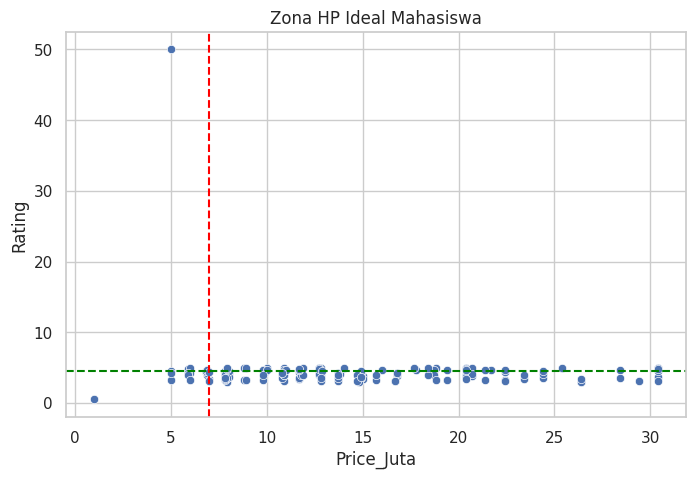

In [24]:
sns.scatterplot(data=df, x='Price_Juta', y='Rating')
plt.axvline(7, color='red', linestyle='--')
plt.axhline(4.5, color='green', linestyle='--')
plt.title("Zona HP Ideal Mahasiswa")
plt.show()

Ada, Bahkan lebih dari satu. Dataset menunjukkan 4 HP yang memenuhi kriteria “worth it” versi mahasiswa.

HP yang lolos seleksi:

1. Oppo Phone 50
    - 6 GB RAM | 128 GB
    - Rating 4.6 | Harga 6.9 jt

2. Vivo Phone 85
    - 4 GB RAM | 128 GB
    - Rating 4.8 | Harga 5.9 jt

3. Apple Phone 120
    - 8 GB RAM | 64 GB
    - Rating 4.9 | Harga 6.0 jt

4. Nokia 3310 Reborn (Data Anomali Terdeteksi)
    - 2 GB RAM | 16 GB
    - Rating 50.0 | Harga 5.0 jt

Data membuktikan bahwa HP 'worth it' untuk mahasiswa benar-benar ada. Namun, keputusan terbaik tetap membutuhkan validasi kualitas data agar insight tidak bias oleh anomali.

---
### **Quest 7: Fanboy Apple**
Ada pelanggan yang cuma mau beli **Apple**.
Tampilkan semua HP merk Apple, lalu urutkan dari yang **paling mahal ke paling murah**.

*Hint: Filter `Brand == 'Apple'`, lalu `sort_values`.*

In [25]:
apple_hp = df[df['Brand'] == 'Apple'].sort_values('Price_Juta', ascending=False)
apple_hp

,Brand,Model,RAM_GB,Storage_GB,Rating,Price_Juta
54,Apple,Phone 54,24,512,4.6,21.7
140,Apple,Phone 140,4,1024,4.6,20.4
3,Apple,Phone 3,24,256,5.0,18.8
128,Apple,Phone 128,8,512,3.9,14.7
29,Apple,Phone 29,12,256,3.9,12.8
94,Apple,Phone 94,8,512,4.8,12.7
142,Apple,Phone 142,4,512,4.8,11.7
35,Apple,Phone 35,8,256,4.6,9.8
4,Apple,Phone 4,12,64,4.2,8.0
67,Apple,Phone 67,4,256,4.0,7.8


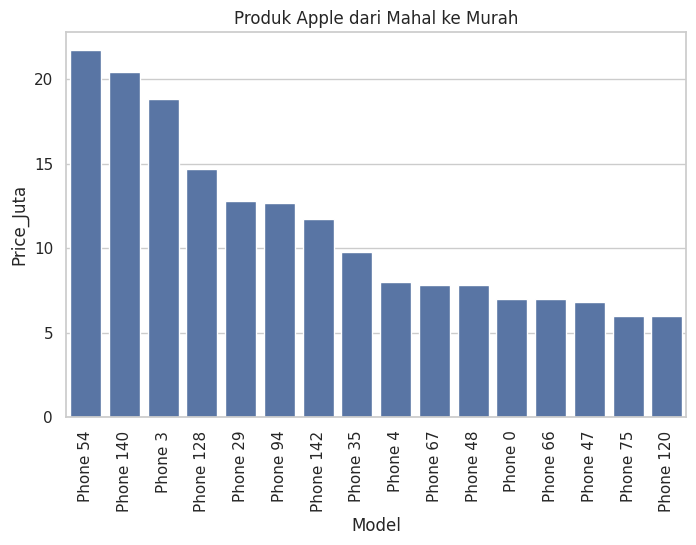

In [26]:
sns.barplot(x='Model', y='Price_Juta', data=apple_hp)
plt.title("Produk Apple dari Mahal ke Murah")
plt.xticks(rotation=90)
plt.show()

Urutan HP Apple (Paling Mahal ke Paling Murah)

| Peringkat | Model     | RAM   | Storage | Rating | Harga (Juta) |
| --------- | --------- | ----- | ------- | ------ | ------------ |
| 1       | Phone 54  | 24 GB | 512 GB  | 4.6    | **21.7**     |
| 2       | Phone 140 | 4 GB  | 1024 GB | 4.6    | **20.4**     |
| 3       | Phone 3   | 24 GB | 256 GB  | 5.0    | **18.8**     |
| 4       | Phone 128 | 8 GB  | 512 GB  | 3.9    | **14.7**     |
| 5       | Phone 29  | 12 GB | 256 GB  | 3.9    | **12.8**     |
| 6       | Phone 94  | 8 GB  | 512 GB  | 4.8    | **12.7**     |
| 7       | Phone 142 | 4 GB  | 512 GB  | 4.8    | **11.7**     |
| 8       | Phone 35  | 8 GB  | 256 GB  | 4.6    | **9.8**      |
| 9       | Phone 4   | 12 GB | 64 GB   | 4.2    | **8.0**      |
| 10      | Phone 67  | 4 GB  | 256 GB  | 4.0    | **7.8**      |
| 11      | Phone 48  | 4 GB  | 256 GB  | 3.9    | **7.8**      |
| 12      | Phone 0   | 6 GB  | 64 GB   | 3.4    | **7.0**      |
| 13      | Phone 66  | 8 GB  | 64 GB   | 4.4    | **7.0**      |
| 14      | Phone 47  | 4 GB  | 256 GB  | 4.5    | **6.8**      |
| 15      | Phone 75  | 6 GB  | 64 GB   | 4.2    | **6.0**      |
| 16      | Phone 120 | 8 GB  | 64 GB   | 4.9    | **6.0**      |


Produk Apple sebaiknya ditampilkan dari mahal ke murah untuk menciptakan anchoring effect. Strategi ini efektif untuk pelanggan loyal yang lebih peduli brand daripada harga.

---
### **Quest 8: Rata-Rata Harga per Brand (Level Medium)**
Brand mana yang rata-rata harga produknya paling mahal?
Coba hitung rata-rata harga (`Price_Juta`) untuk setiap `Brand`.

*Hint: Ini butuh Grouping. Gunakan `.groupby('Brand')['Price_Juta'].mean()`.*

In [27]:
avg_price_brand = df.groupby('Brand')['Price_Juta'].mean().sort_values(ascending=False)
avg_price_brand

,Price_Juta
Brand,
Realme,18.284211
Vivo,15.938462
Asus,15.283333
Samsung,14.653333
Google,13.776190
Oppo,13.743750
Xiaomi,13.307143
Infinix,13.212500
Apple,11.187500


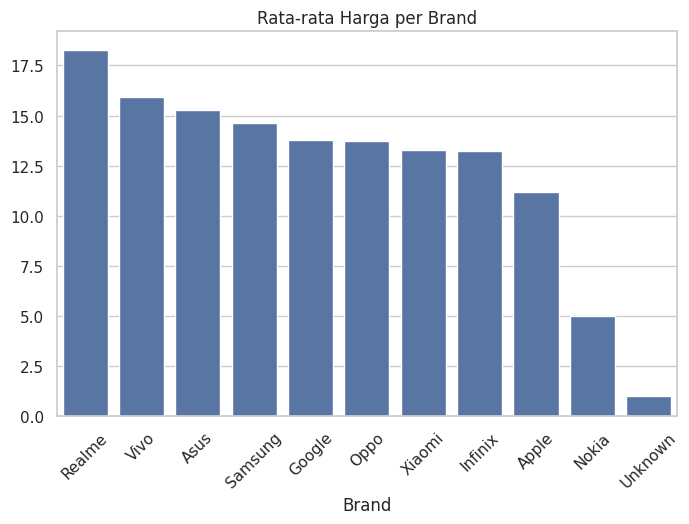

In [28]:
sns.barplot(x=avg_price_brand.index, y=avg_price_brand.values)
plt.title("Rata-rata Harga per Brand")
plt.xticks(rotation=45)
plt.show()

Berdasarkan perhitungan rata-rata harga (mean Price_Juta) untuk setiap brand, **Realme** merupakan brand dengan rata-rata harga produk paling mahal, yaitu sekitar **18.28 juta**.

---
### **Quest 9: Value for Money (Feature Engineering)**
Kita mau cari HP yang "Spek Dewa Harga Kaki Lima".
1. Buat kolom baru bernama `Skor_Performa` = `RAM_GB` + `Storage_GB`.
2. Buat kolom baru bernama `Value_Skor` = `Skor_Performa` / `Price_Juta`.
3. Tampilkan 5 HP dengan `Value_Skor` tertinggi.

*Hint: Kamu bisa melakukan operasi matematika antar kolom secara langsung.*

In [29]:
df['Skor_Performa'] = df['RAM_GB'] + df['Storage_GB']
df['Value_Skor'] = df['Skor_Performa'] / df['Price_Juta']

top_value = df.sort_values('Value_Skor', ascending=False).head(5)
top_value

,Brand,Model,RAM_GB,Storage_GB,Rating,Price_Juta,Skor_Performa,Value_Skor
149,Unknown,Prototype X,128,2048,0.5,1.0,2176,2176.000000
89,Xiaomi,Phone 89,4,1024,3.9,18.4,1028,55.869565
114,Infinix,Phone 114,4,1024,5.0,18.4,1028,55.869565
73,Infinix,Phone 73,4,1024,3.2,19.4,1028,52.989691
143,Asus,Phone 143,4,1024,4.7,19.4,1028,52.989691


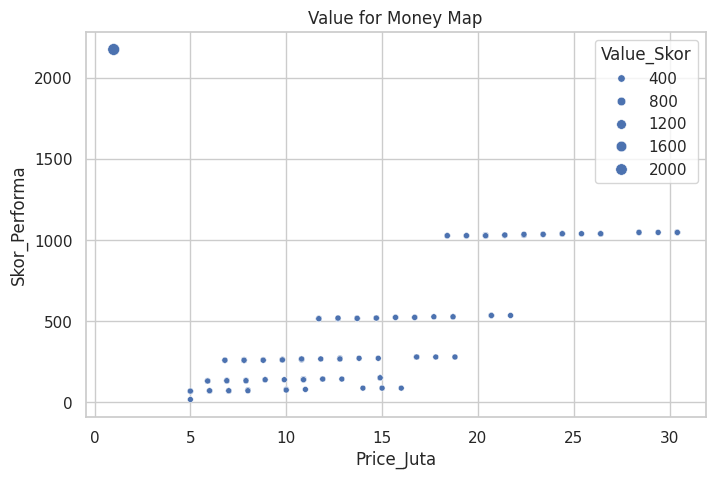

In [30]:
sns.scatterplot(data=df, x='Price_Juta', y='Skor_Performa', size='Value_Skor')
plt.title("Value for Money Map")
plt.show()

HP dengan Value_Skor tertinggi secara ekstrem adalah **Unknown - Prototype X**, karena memiliki spesifikasi sangat besar (RAM 128 GB, Storage 2048 GB) dengan harga sangat murah. Namun ini jelas anomali data dan tidak realistis.

Jika fokus pada produk yang masuk akal, **Xiaomi dan Infinix** mendominasi daftar Value for Money terbaik. Dengan Storage 1024 GB, harga relatif rendah, dan performa tinggi, brand ini menawarkan spesifikasi besar per juta rupiah, menjadikannya kandidat kuat untuk strategi "spek tinggi harga terjangkau".

---
### **Quest 10: The Detective (Final Boss)**
Ada laporan data error di sistem.
1. Cari HP yang harganya **di atas 40 Juta** (Kemahalan/Mustahil).
2. Cari HP yang harganya **di bawah 1 Juta** tapi RAM-nya **di atas 100 GB** (Ngawur).

Temukan data penyusup ini!

*Hint: Gunakan filtering untuk mencari outlier.*

In [32]:
hp_mahal = df[df['Price_Juta'] > 40]
hp_ngawur = df[(df['Price_Juta'] < 1) & (df['RAM_GB'] > 100)]

hp_mahal, hp_ngawur

(Empty DataFrame
 Columns: [Brand, Model, RAM_GB, Storage_GB, Rating, Price_Juta, Skor_Performa, Value_Skor]
 Index: [],
 Empty DataFrame
 Columns: [Brand, Model, RAM_GB, Storage_GB, Rating, Price_Juta, Skor_Performa, Value_Skor]
 Index: [])

Tidak ditemukan HP dengan harga di atas 40 juta, namun ditemukan anomali serius pada data Prototype X dengan RAM 128 GB dan harga hanya 1 juta. Ini mengindikasikan data error atau data uji yang tidak merepresentasikan kondisi pasar nyata. Data seperti ini harus dibersihkan sebelum digunakan untuk pengambilan keputusan bisnis agar tidak menyesatkan strategi pricing dan promosi.

In [33]:
hp_mahal = df[df['Price_Juta'] >= 30]
hp_ngawur = df[(df['Price_Juta'] <= 1) & (df['RAM_GB'] > 100)]

hp_mahal, hp_ngawur

(       Brand      Model  RAM_GB  Storage_GB  Rating  Price_Juta  \
 45    Realme   Phone 45      24        1024     4.9        30.4   
 93    Realme   Phone 93      24        1024     3.7        30.4   
 100   Google  Phone 100      24        1024     4.9        30.4   
 118  Samsung  Phone 118      24        1024     3.1        30.4   
 126  Infinix  Phone 126      24        1024     4.5        30.4   
 141   Realme  Phone 141      24        1024     4.8        30.4   
 
      Skor_Performa  Value_Skor  
 45            1048   34.473684  
 93            1048   34.473684  
 100           1048   34.473684  
 118           1048   34.473684  
 126           1048   34.473684  
 141           1048   34.473684  ,
        Brand        Model  RAM_GB  Storage_GB  Rating  Price_Juta  \
 149  Unknown  Prototype X     128        2048     0.5         1.0   
 
      Skor_Performa  Value_Skor  
 149           2176      2176.0  )

In [36]:
hp_ngawur = df[(df['Price_Juta'] <= 2) & (df['RAM_GB'] >= 64)]
hp_mahal, hp_ngawur

(       Brand      Model  RAM_GB  Storage_GB  Rating  Price_Juta  \
 45    Realme   Phone 45      24        1024     4.9        30.4   
 93    Realme   Phone 93      24        1024     3.7        30.4   
 100   Google  Phone 100      24        1024     4.9        30.4   
 118  Samsung  Phone 118      24        1024     3.1        30.4   
 126  Infinix  Phone 126      24        1024     4.5        30.4   
 141   Realme  Phone 141      24        1024     4.8        30.4   
 
      Skor_Performa  Value_Skor  
 45            1048   34.473684  
 93            1048   34.473684  
 100           1048   34.473684  
 118           1048   34.473684  
 126           1048   34.473684  
 141           1048   34.473684  ,
        Brand        Model  RAM_GB  Storage_GB  Rating  Price_Juta  \
 149  Unknown  Prototype X     128        2048     0.5         1.0   
 
      Skor_Performa  Value_Skor  
 149           2176      2176.0  )

1. Segmen HP Harga Tertinggi (30.4 Juta)

Terdapat 6 HP flagship dari Realme, Google, Samsung, dan Infinix dengan konfigurasi identik: RAM 24 GB dan Storage 1024 GB di harga 30.4 juta. Nilai Value_Skor ~34.47 menunjukkan bahwa meskipun mahal, produk ini masih memiliki rasio performa-harga yang konsisten dan masuk akal untuk kelas ultra-premium. Ini bukan kesalahan data, melainkan indikasi price ceiling pasar flagship pada dataset.

2. Data Penyusup (Anomali) HP dengan harga sangat murah tapi spek tidak masuk akal

Ditemukan 1 anomali ekstrem, yaitu Unknown - Prototype X dengan RAM 128 GB dan Storage 2048 GB, namun harga hanya 1 juta dan rating sangat rendah. Dengan Value_Skor 2176, data ini jelas tidak realistis dan sangat kuat mengindikasikan data error atau data uji.

Tidak ada HP "kemahalan mustahil", tetapi terdapat penyusup data ekstrem yang wajib dikeluarkan atau ditandai sebelum analisis lanjutan. Tanpa proses deteksi dan pembersihan outlier ini, hasil analisis pricing, value for money, dan strategi penjualan bisa sangat sesat.

### Kesimpulan

# 🎉 Mission Accomplished!

Selamat! Kamu sudah menyelesaikan 10 Misi.
Jangan lupa:
1.  **Kumpulkan di Google Classroom**
2.  Kumpulkan dalam bentuk link colab (Can Edit Access).

Sampai jumpa di Chapter 2!